## Task 1

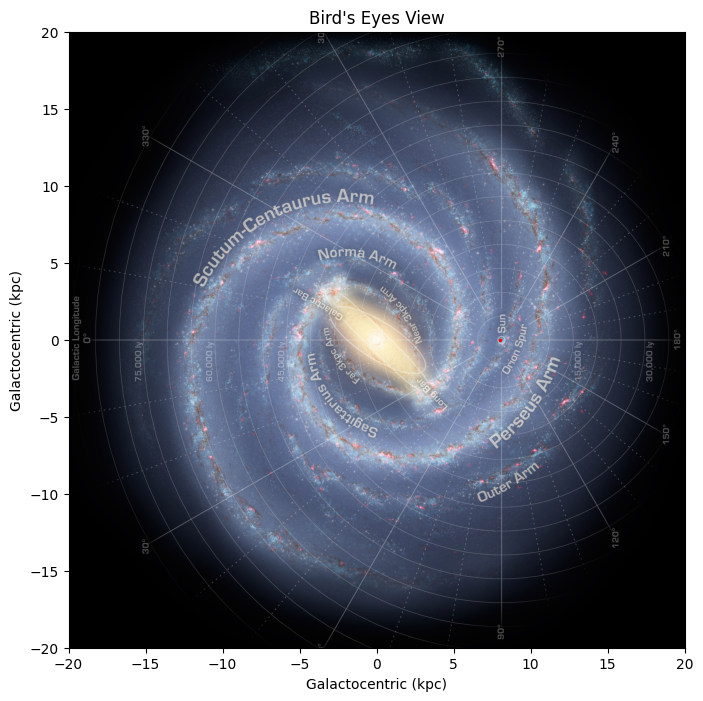

In [1]:
from Task1 import gen_milkyway

gen_milkyway()

## Task 2

Generating sectors for various celestial objects:
1. Andromeda Galaxy:
2. Omega Centauri (A large collection of stars)
3. Large Magellanic Cloud (Dwarf galaxy)
4. Eagle Nebula


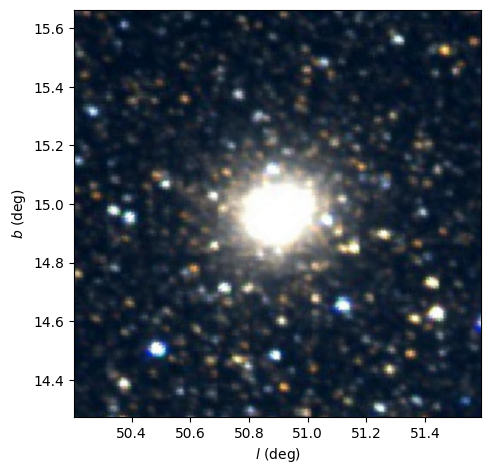

In [2]:
from Task2 import gen_milkyway_sector

print("Generating sectors for various celestial objects:")
print("1. Andromeda Galaxy:")
print("2. Omega Centauri (A large collection of stars)")
print("3. Large Magellanic Cloud (Dwarf galaxy)")
print("4. Eagle Nebula")

# gen_milkyway_sector("M31", 8800) # Andromeda Galaxy
# gen_milkyway_sector("LMC", 3500) # Large Magellanic Cloud
# gen_milkyway_sector("M16", 2500)  # Eagle Nebula
omega_centauri = gen_milkyway_sector("NGC 5139", 2500)   # Omega Centauri

## Task 3

In [3]:
from Task3 import plt2rgbarr

rgb_array = plt2rgbarr(omega_centauri)
print(f"RGB array shape for Omega Centauri sector: {rgb_array.shape}")

RGB array shape for Omega Centauri sector: (500, 500, 3)


## Task 4

The first step in generating categories from the data is to determine what property of the data is the most meaningful. The array we are working with contains a collection of pixels of various colors. 

My first though is that the brightness or "whiteness" of a pixel could be interesting as it means there is a star there and stars have a lot of gravity so there is probably other stuff there as well. Additionally areas of medium brightness could indicate the existence of an object that is reflecting light such as a nebula.

Another interesting property of the data could be the color/hue, stars have different color depending on their size and life-cycle stage so the color data could tell us something about the age and size of objects around the galaxy and might be worth investigating further.

For this assignment we will use the brightness of the pixels to generate the categories. We will create 3 different categories, "dark" "medium" and "bright". To find the brightness of a pixel we are calculating the sum of the rgb values. Based on this sum we assign each pixel a number from 0-2 indicating if it is dark, medium or bright:


$sum < 250$: dark  
$250 <= sum < 400$: medium  
$sum > 400$: bright  


Created 500 categories from Omega Centauri sector.


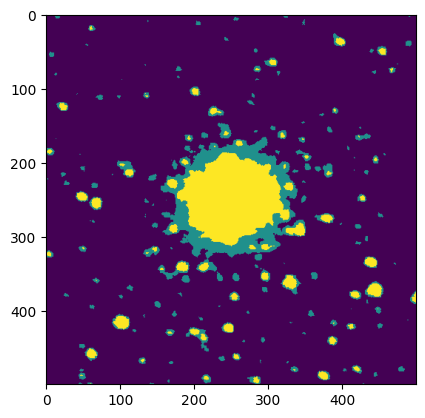

In [4]:
from Task4 import encode_rgb_data
from matplotlib import pyplot as plt

categories = encode_rgb_data(rgb_array)
print(f"Created {len(categories)} categories from Omega Centauri sector.")

# Visualize the categories
plt.imshow(categories)
plt.show()

## Task 5

Using K-means clustering on the brightness encoding.

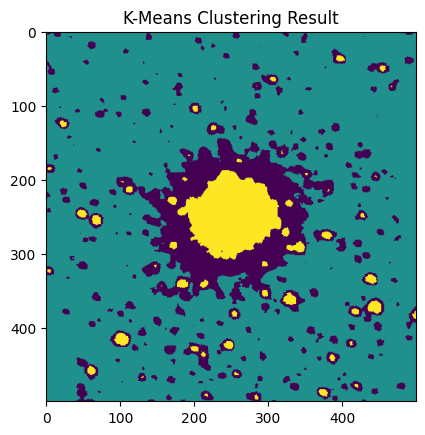

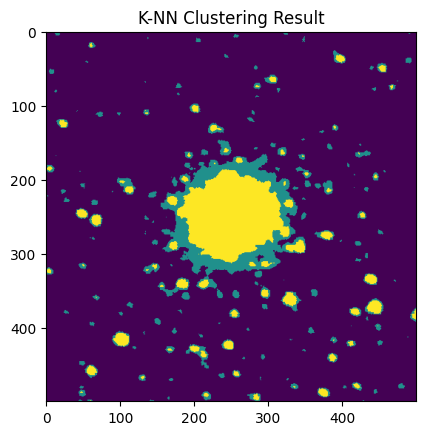

In [5]:
from Task5 import kmeans_clustering

clustered_data = kmeans_clustering(rgb_array, n_clusters=3)

# Reshape clustered data back to image dimensions for visualization
cluster_plot_data = clustered_data.reshape(rgb_array.shape[0], rgb_array.shape[1])

# plot the clustered data
plt.imshow(cluster_plot_data, cmap='viridis')
plt.title("K-Means Clustering Result")
plt.show()


# k-nn clustering
from Task5 import knn_clustering
knn_clustered_data = knn_clustering(rgb_array, categories)
# reshape
knn_cluster_plot_data = knn_clustered_data.reshape(rgb_array.shape[0], rgb_array.shape[1])
plt.imshow(knn_cluster_plot_data, cmap='viridis')
plt.title("K-NN Clustering Result")
plt.show()

## Task 6

Overimposing the original image over the cluster generated by the k-means method.

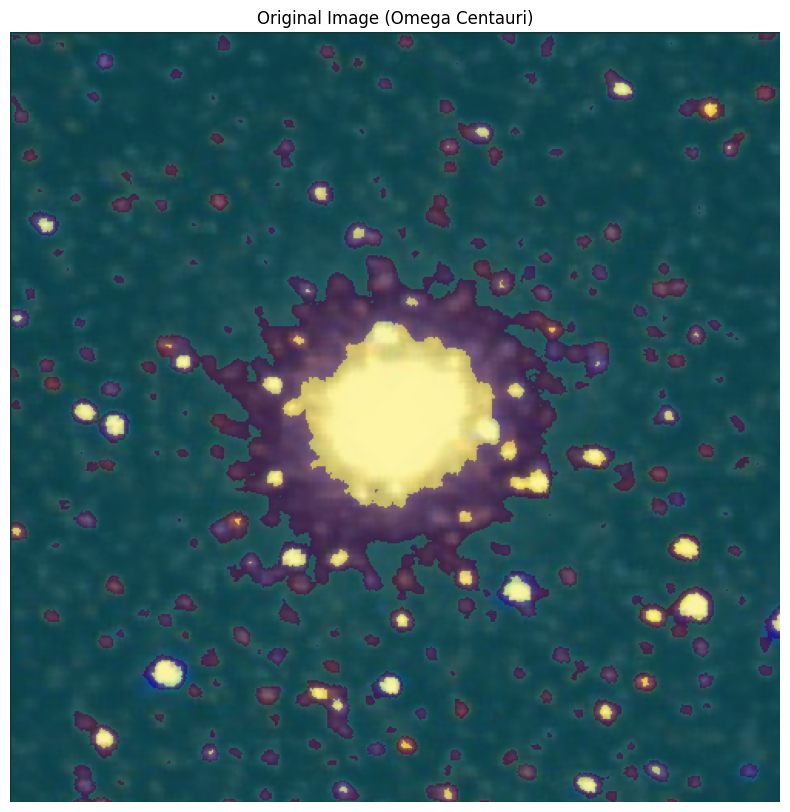

In [ ]:
from task6 import overlay_clustered_image

overlay_clustered_image(rgb_array, cluster_plot_data, alpha=0.4)